# Experimentos del TP1 de regresión

Este notebook reúne, en un solo lugar y con el código a la vista, los experimentos que se hicieron para tomar las decisiones de criterio del TP (`TP-regresion-AA1.ipynb`). Todas las tablas y gráficos se generan al ejecutar el notebook; ningún resultado está escrito a mano.

**Cómo está armado**
1. Se carga y limpia el dataset igual que en el TP.
2. Una función, `pipeline(...)`, reproduce el preprocesamiento y el modelado del TP y permite activar o desactivar cada decisión (estratificación, imputación de CHAS, variables excluidas, Yeo-Johnson, selección de `lr`/`epochs`, grilla de Ridge).
3. Se valida que el pipeline reproduce los resultados del notebook del TP.
4. Cada experimento cambia **un solo factor** respecto de una configuración base y se repite con varias semillas (`random_state` del split), porque con un único split el R² de test varía mucho.

**Cómo se comparan las configuraciones.** Con la misma semilla, dos configuraciones del mismo experimento usan las mismas filas de train y de test, así que se comparan **por diferencia pareada**: para cada semilla se calcula `métrica(configuración) − métrica(base)` y se mira la media y el desvío de esas diferencias. Eso cancela la variabilidad de "la partición fue fácil o difícil". La excepción son los esquemas de estratificación (experimento 6): al cambiar el split cambian las filas de test, así que allí solo se puede comparar el desvío entre semillas.

**Requisitos.** Solo el experimento 1 usa CatBoost (`pip install catboost`); si no está instalado se saltean esas configuraciones. Los resultados se guardan también como CSV en `resultados/`. Un resumen escrito de las conclusiones está en [`../EXPERIMENTOS.md`](../EXPERIMENTOS.md).

## 0. Preparación: datos y funciones

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import RobustScaler, StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

try:
    from catboost import CatBoostClassifier
    HAY_CATBOOST = True
except ImportError:
    HAY_CATBOOST = False
    print('catboost no está instalado: se saltean las configuraciones con imputación por CatBoost (pip install catboost).')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize': (10, 4.5), 'figure.dpi': 100})
os.makedirs('resultados', exist_ok=True)

SEMILLAS = [42, 1, 2, 3, 4]              # 5 semillas para los experimentos 1 a 5
SEMILLAS_10 = [42, 1, 2, 3, 4, 5, 6, 7, 8, 9]   # 10 semillas para el experimento 6
MODELOS = ['LinearRegression', 'Gradient Descent', 'Ridge', 'Lasso', 'ElasticNet']

### Carga y limpieza (igual que en el TP)
Se eliminan las filas sin `MEDV` y las que tienen más del 50% de las columnas faltantes. La limpieza se hace antes del split porque son reglas fijas que no usan estadísticos del dataset.

In [2]:
df_raw = pd.read_csv('../data/house-prices-tp.csv')

df0 = df_raw.dropna(subset=['MEDV'])
pct_nulos_fila = df0.isnull().sum(axis=1) / df0.shape[1] * 100
df0 = df0[pct_nulos_fila <= 50]

COL_CAT = 'CHAS'
COL_NUM = [c for c in df_raw.select_dtypes(include=[np.number]).columns if c not in ('MEDV', COL_CAT)]
print(f'Dataset original: {df_raw.shape[0]} filas | tras la limpieza: {df0.shape[0]} filas')
print('Variables numéricas:', COL_NUM)

Dataset original: 556 filas | tras la limpieza: 532 filas
Variables numéricas: ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


### Gradiente descendente y selección de sus hiperparámetros
Es la misma implementación del TP (sin gráficos). `lr` y `epochs` se eligen sobre una grilla; el método de selección es uno de los factores que se comparan en el experimento 4:
- `test_fijo`: `lr=0.1, epochs=200`, los valores que en la versión anterior del TP se elegían mirando el R² de test (con fuga de información).
- `holdout`: separa el 20% de train como validación y elige el mayor R² de validación.
- `kfold`: validación cruzada de 5 folds dentro de train, eligiendo el menor MSE de validación promedio (mismo criterio que `LassoCV` y `RidgeCV`).

In [3]:
GRILLA_GD = [(lr, ep) for lr in [0.01, 0.05, 0.1, 0.3] for ep in [100, 200, 500]]

def gd_pesos(X, y, lr, epochs, seed):
    n, m = X.shape
    Xb = np.hstack((np.ones((n, 1)), X))
    np.random.seed(seed)                      # misma inicialización que en el TP
    W = np.random.randn(m + 1).reshape(m + 1, 1)
    for _ in range(epochs):
        error = y - Xb @ W
        grad = (-2 / n) * np.sum(error * Xb, axis=0)
        W = W - lr * grad.reshape(-1, 1)
    return W

def predecir(W, X):
    return (np.hstack((np.ones((X.shape[0], 1)), X)) @ W).ravel()

def mse_o_inf(W, X, y):
    pred = predecir(W, X)
    return np.mean((y.ravel() - pred) ** 2) if np.all(np.isfinite(pred)) else np.inf   # inf si el GD divergió

def elegir_gd(X, y, metodo, seed):
    if metodo == 'test_fijo':
        return 0.1, 200
    if metodo == 'holdout':
        Xtr, Xval, ytr, yval = train_test_split(X, y, test_size=0.2, random_state=seed)
        puntajes = []
        for lr, ep in GRILLA_GD:
            W = gd_pesos(Xtr, ytr, lr, ep, seed)
            pred = predecir(W, Xval)
            r2 = metrics.r2_score(yval.ravel(), pred) if np.all(np.isfinite(pred)) else -np.inf
            puntajes.append(-r2)              # se minimiza -R²
        return GRILLA_GD[int(np.argmin(puntajes))]
    if metodo == 'kfold':
        kf = KFold(n_splits=5, shuffle=True, random_state=seed)
        puntajes = []
        for lr, ep in GRILLA_GD:
            mses = []
            for i_tr, i_val in kf.split(X):
                W = gd_pesos(X[i_tr], y[i_tr], lr, ep, seed)
                mses.append(mse_o_inf(W, X[i_val], y[i_val]))
            puntajes.append(np.mean(mses))
        return GRILLA_GD[int(np.argmin(puntajes))]
    raise ValueError(metodo)

### El pipeline
`pipeline(seed, ...)` hace, en este orden y ajustando siempre solo con train (para evitar data leakage): split (con o sin estratificación) → imputación de CHAS → `RobustScaler` + `KNNImputer` para las numéricas → `log1p` en CRIM y DIS → (opcional) Yeo-Johnson en B → `StandardScaler` → modelos. Devuelve una fila por modelo con sus métricas.

Parámetros (cada experimento cambia uno):
- `estratificar`: `'none'`, `'chas'` (CHAS, con NaN como tercer estrato), `'medv'` (5 quintiles de MEDV) o `'chas_medv'` (CHAS × 3 terciles de MEDV).
- `imputar_chas`: `'moda'` (moda de train) o `'catboost'` (clasificador entrenado con las filas de train con CHAS conocida).
- `excluir`: variables que se sacan del modelo.
- `yeo_johnson`: aplica `PowerTransformer` a B.
- `metodo_gd`: `'test_fijo'`, `'holdout'` o `'kfold'`.
- `ridge_alphas`: `'defecto'` (grilla por defecto de `RidgeCV`, 0.1, 1 y 10) o `'ancha'` (`np.logspace(-2, 3, 50)`).

In [4]:
def clave_estratificacion(X, Y, esquema):
    chas = X[COL_CAT].fillna(-1)              # el NaN de CHAS solo se usa aquí, X conserva sus NaN
    if esquema == 'none':
        return None
    if esquema == 'chas':
        return chas
    if esquema == 'medv':
        return pd.qcut(Y, 5, labels=False)
    if esquema == 'chas_medv':
        return chas.astype(str) + '_' + pd.qcut(Y, 3, labels=False).astype(str)
    raise ValueError(esquema)

def imputar_chas_catboost(X_train, X_test, seed):
    conocidas = X_train[X_train[COL_CAT].notna()]
    modelo = CatBoostClassifier(iterations=500, learning_rate=0.05, depth=4, verbose=False, random_seed=seed, allow_writing_files=False)
    modelo.fit(conocidas.drop(columns=COL_CAT), conocidas[COL_CAT].astype(int))
    tr, te = X_train.copy(), X_test.copy()
    for d in (tr, te):
        faltan = d[COL_CAT].isna()
        if faltan.any():
            d.loc[faltan, COL_CAT] = modelo.predict(d.loc[faltan].drop(columns=COL_CAT)).ravel()
    return tr, te

def pipeline(seed, estratificar='chas', imputar_chas='moda', excluir=(), yeo_johnson=False,
             metodo_gd='kfold', ridge_alphas='defecto'):
    cols_num = [c for c in COL_NUM if c not in excluir]
    X = df0[cols_num + [COL_CAT]]
    Y = df0['MEDV']

    # 1) split antes de imputar y escalar
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=seed, stratify=clave_estratificacion(X, Y, estratificar))

    # 2) imputación de CHAS (ajustada solo con train)
    if imputar_chas == 'moda':
        imp = SimpleImputer(strategy='most_frequent').fit(X_train[[COL_CAT]])
        tr, te = X_train.copy(), X_test.copy()
        tr[COL_CAT] = imp.transform(X_train[[COL_CAT]]).ravel()
        te[COL_CAT] = imp.transform(X_test[[COL_CAT]]).ravel()
    else:
        tr, te = imputar_chas_catboost(X_train, X_test, seed)

    # 3) RobustScaler -> KNNImputer -> volver a la escala original (fit solo en train)
    rob = RobustScaler()
    tr_s = pd.DataFrame(rob.fit_transform(tr[cols_num]), columns=cols_num, index=tr.index)
    te_s = pd.DataFrame(rob.transform(te[cols_num]), columns=cols_num, index=te.index)
    knn = KNNImputer(n_neighbors=5)
    tr[cols_num] = rob.inverse_transform(knn.fit_transform(tr_s))
    te[cols_num] = rob.inverse_transform(knn.transform(te_s))

    # 4) transformaciones de las variables
    for col in ['CRIM', 'DIS']:
        tr[col] = np.log1p(tr[col]); te[col] = np.log1p(te[col])
    if yeo_johnson:
        pt = PowerTransformer(method='yeo-johnson', standardize=False)
        tr['B'] = pt.fit_transform(tr[['B']]).ravel()
        te['B'] = pt.transform(te[['B']]).ravel()

    # 5) estandarización final (fit solo en train)
    sc = StandardScaler()
    Xtr = sc.fit_transform(tr); Xte = sc.transform(te)
    ytr = y_train.to_numpy().reshape(-1, 1); yte = y_test.to_numpy().reshape(-1, 1)

    # 6) modelos
    predicciones, extra = {}, {}
    lr_m = LinearRegression().fit(Xtr, y_train)
    predicciones['LinearRegression'] = (lr_m.predict(Xtr), lr_m.predict(Xte))

    lr_gd, ep_gd = elegir_gd(Xtr, ytr, metodo_gd, seed)      # solo con train
    W = gd_pesos(Xtr, ytr, lr_gd, ep_gd, seed)
    predicciones['Gradient Descent'] = (predecir(W, Xtr), predecir(W, Xte))
    extra['Gradient Descent'] = f'lr={lr_gd}, epochs={ep_gd}'

    alphas = dict(alphas=np.logspace(-2, 3, 50)) if ridge_alphas == 'ancha' else {}
    for nombre, modelo in [('Ridge', RidgeCV(cv=5, **alphas)), ('Lasso', LassoCV(cv=5)), ('ElasticNet', ElasticNetCV(cv=5))]:
        modelo.fit(Xtr, y_train)                              # alpha elegido con CV dentro de train
        predicciones[nombre] = (modelo.predict(Xtr), modelo.predict(Xte))
        extra[nombre] = round(float(modelo.alpha_), 4)

    filas = []
    for nombre, (ptr, pte) in predicciones.items():
        filas.append({'modelo': nombre,
                      'r2_train': metrics.r2_score(y_train, ptr), 'r2_test': metrics.r2_score(y_test, pte),
                      'rmse_train': np.sqrt(metrics.mean_squared_error(y_train, ptr)),
                      'rmse_test': np.sqrt(metrics.mean_squared_error(y_test, pte)),
                      'mae_test': metrics.mean_absolute_error(y_test, pte),
                      'hiperparametros': extra.get(nombre, '')})
    return pd.DataFrame(filas)

### Utilidades para correr experimentos y mostrar resultados

In [5]:
BASE = dict(estratificar='chas', imputar_chas='moda', excluir=(), yeo_johnson=False,
            metodo_gd='kfold', ridge_alphas='defecto')

_cache = {}
def correr(nombre, configs, semillas):
    """Corre cada configuración (dict etiqueta -> cambios sobre BASE) con cada semilla y guarda un CSV."""
    filas = []
    for etiqueta, cambios in configs.items():
        for s in semillas:
            params = {**BASE, **cambios}
            clave = (s, tuple(sorted(params.items())))
            if clave not in _cache:
                _cache[clave] = pipeline(s, **params)
            res = _cache[clave].copy()
            res.insert(0, 'configuracion', etiqueta); res.insert(1, 'semilla', s)
            filas.append(res)
    df = pd.concat(filas, ignore_index=True)
    df.to_csv(f'resultados/{nombre}.csv', index=False)
    return df

def resumen(df, metrica='r2_test', modelos=MODELOS):
    """Media ± desvío entre semillas de la métrica, por modelo y configuración."""
    orden = list(dict.fromkeys(df['configuracion']))
    g = df[df['modelo'].isin(modelos)].groupby(['modelo', 'configuracion'])[metrica].agg(['mean', 'std'])
    tabla = (g['mean'].round(3).astype(str) + ' ± ' + g['std'].round(3).astype(str)).unstack('configuracion')
    return tabla.reindex(index=modelos, columns=orden)

def pareado(df, base, metrica='r2_test', modelos=MODELOS):
    """Diferencia pareada por semilla contra la configuración `base`: media ± desvío y en cuántas semillas empeora."""
    ancho = df.pivot_table(index=['modelo', 'semilla'], columns='configuracion', values=metrica)
    filas = {}
    for modelo in modelos:
        fila = {}
        for conf in [c for c in ancho.columns if c != base]:
            d = ancho.loc[modelo][conf] - ancho.loc[modelo][base]
            empeora = int((d < 0).sum()) if metrica.startswith('r2') else int((d > 0).sum())
            fila[conf] = f'{d.mean():+.3f} ± {d.std():.3f} (peor en {empeora}/{len(d)})'
        filas[modelo] = fila
    return pd.DataFrame(filas).T

def grafico_por_semilla(df, metrica='r2_test', modelo='LinearRegression'):
    d = df[df['modelo'] == modelo]
    fig, ax = plt.subplots()
    sns.lineplot(data=d, x='semilla', y=metrica, hue='configuracion', style='configuracion', markers=True, dashes=False, ax=ax)
    ax.set_xticks(sorted(d['semilla'].unique())); ax.set_title(f'{metrica} de {modelo} por semilla (misma semilla = mismo split)')
    ax.legend(title='configuración', bbox_to_anchor=(1.02, 1), loc='upper left'); plt.show()

## 1. Validación del pipeline
Antes de usarlo se comprueba que reproduce los resultados del notebook del TP para la semilla 42, con la configuración del TP (split estratificado por CHAS, CHAS con la moda, RAD excluida y `lr`/`epochs` por K-Fold). Los valores de referencia son los que imprime la última tabla de `TP-regresion-AA1.ipynb`.

In [6]:
referencia_tp = {'LinearRegression': 0.6988, 'Gradient Descent': 0.7047, 'Ridge': 0.7022, 'Lasso': 0.7049, 'ElasticNet': 0.7042}  # R² de test del TP
mio = pipeline(42, estratificar='chas', imputar_chas='moda', excluir=('RAD',), metodo_gd='kfold').set_index('modelo')['r2_test']
validacion = pd.DataFrame({'R² test (TP)': pd.Series(referencia_tp), 'R² test (este notebook)': mio.round(4)})
validacion['coincide (±0.001)'] = (validacion['R² test (TP)'] - validacion['R² test (este notebook)']).abs() < 0.001
validacion

,R² test (TP),R² test (este notebook),coincide (±0.001)
LinearRegression,0.6988,0.6988,True
Gradient Descent,0.7047,0.7047,True
Ridge,0.7022,0.7022,True
Lasso,0.7049,0.7049,True
ElasticNet,0.7042,0.7042,True


## 2. Experimento 1: estratificación por CHAS e imputación de CHAS
**Pregunta.** ¿Estratificar el split por CHAS y/o imputar CHAS con la moda en vez de con CatBoost cambia los resultados?

Se combinan los dos factores (2 × 2). Como la estratificación cambia las filas de test, las columnas con y sin estratificación **no** son comparables por diferencia pareada; sí lo son las dos formas de imputar dentro de cada esquema de split.

In [7]:
config_e1 = {'sin estratificar + moda': dict(estratificar='none', imputar_chas='moda'),
             'estratificado + moda': dict(estratificar='chas', imputar_chas='moda')}
if HAY_CATBOOST:
    config_e1 = {'sin estratificar + CatBoost': dict(estratificar='none', imputar_chas='catboost'),
                 **config_e1,
                 'estratificado + CatBoost': dict(estratificar='chas', imputar_chas='catboost')}
e1 = correr('exp1_estratificacion_imputacion', config_e1, SEMILLAS)
resumen(e1, 'r2_test')

configuracion,sin estratificar + CatBoost,sin estratificar + moda,estratificado + moda,estratificado + CatBoost
modelo,,,,
LinearRegression,0.562 ± 0.113,0.564 ± 0.116,0.596 ± 0.119,0.595 ± 0.118
Gradient Descent,0.552 ± 0.104,0.555 ± 0.107,0.594 ± 0.115,0.594 ± 0.117
Ridge,0.568 ± 0.101,0.57 ± 0.103,0.597 ± 0.116,0.596 ± 0.116
Lasso,0.555 ± 0.105,0.557 ± 0.108,0.586 ± 0.102,0.585 ± 0.101
ElasticNet,0.559 ± 0.1,0.562 ± 0.103,0.587 ± 0.102,0.586 ± 0.101


In [8]:
resumen(e1, 'rmse_test')

configuracion,sin estratificar + CatBoost,sin estratificar + moda,estratificado + moda,estratificado + CatBoost
modelo,,,,
LinearRegression,5.88 ± 0.875,5.867 ± 0.91,6.066 ± 1.004,6.074 ± 1.007
Gradient Descent,5.95 ± 0.792,5.932 ± 0.832,6.086 ± 0.979,6.087 ± 0.996
Ridge,5.852 ± 0.82,5.835 ± 0.848,6.064 ± 0.991,6.075 ± 0.994
Lasso,5.93 ± 0.809,5.915 ± 0.848,6.169 ± 0.901,6.173 ± 0.905
ElasticNet,5.908 ± 0.807,5.89 ± 0.843,6.159 ± 0.904,6.171 ± 0.906


--- sin estratificar: diferencia de R² de test (moda − CatBoost)


,sin estratificar + moda
LinearRegression,+0.002 ± 0.010 (peor en 2/5)
Gradient Descent,+0.003 ± 0.011 (peor en 2/5)
Ridge,+0.002 ± 0.009 (peor en 2/5)
Lasso,+0.002 ± 0.011 (peor en 2/5)
ElasticNet,+0.003 ± 0.010 (peor en 2/5)


--- estratificado: diferencia de R² de test (moda − CatBoost)


,estratificado + moda
LinearRegression,+0.001 ± 0.005 (peor en 1/5)
Gradient Descent,+0.000 ± 0.007 (peor en 2/5)
Ridge,+0.001 ± 0.005 (peor en 1/5)
Lasso,+0.000 ± 0.007 (peor en 2/5)
ElasticNet,+0.001 ± 0.006 (peor en 1/5)


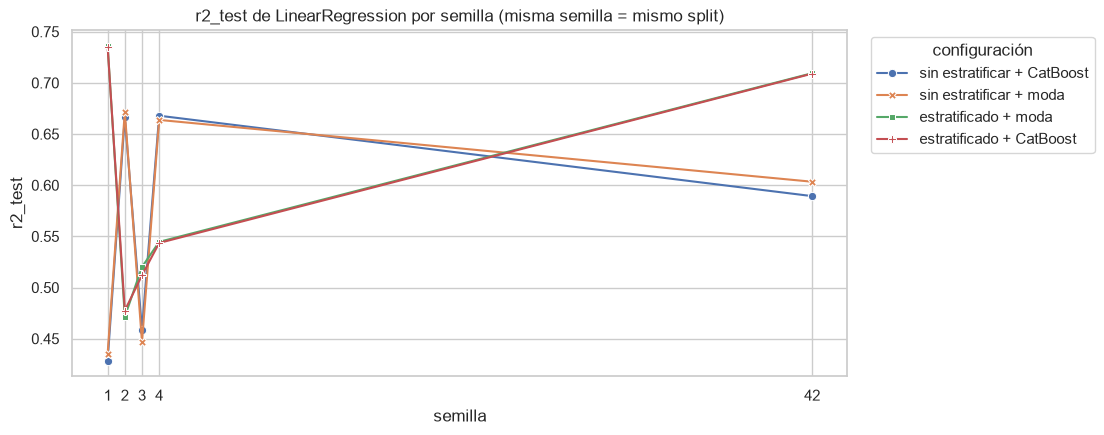

In [9]:
# Efecto de imputar con la moda en lugar de CatBoost (mismo split en cada esquema)
if HAY_CATBOOST:
    for esquema in ['sin estratificar', 'estratificado']:
        sub = e1[e1['configuracion'].isin([f'{esquema} + CatBoost', f'{esquema} + moda'])]
        print(f'--- {esquema}: diferencia de R² de test (moda − CatBoost)')
        display(pareado(sub, base=f'{esquema} + CatBoost'))
grafico_por_semilla(e1)

## 3. Experimento 2: colinealidad (RAD y TAX)
**Pregunta.** RAD y TAX están muy correlacionadas. ¿Qué pasa con las métricas y con los coeficientes al sacar una de ellas o las dos?

Primero se mide la colinealidad con el factor de inflación de la varianza (VIF), calculado con las filas completas.

In [10]:
X_vif = df0[COL_NUM + [COL_CAT]].dropna()
Z = (X_vif - X_vif.mean()) / X_vif.std()
vif = pd.Series(np.diag(np.linalg.inv(np.corrcoef(Z.values, rowvar=False))), index=Z.columns).sort_values(ascending=False)
print('Correlación RAD-TAX:', round(df0['RAD'].corr(df0['TAX']), 2))
vif.round(2).to_frame('VIF')

Correlación RAD-TAX: 0.88


,VIF
TAX,9.01
RAD,7.48
NOX,4.39
INDUS,3.99
DIS,3.96
AGE,3.10
LSTAT,2.94
ZN,2.30
RM,1.93
PTRATIO,1.80


In [11]:
e2 = correr('exp2_colinealidad', {'todas': dict(),
                                   'sin RAD': dict(excluir=('RAD',)),
                                   'sin TAX': dict(excluir=('TAX',)),
                                   'sin ambas': dict(excluir=('RAD', 'TAX'))}, SEMILLAS)
resumen(e2, 'r2_test')

configuracion,todas,sin RAD,sin TAX,sin ambas
modelo,,,,
LinearRegression,0.596 ± 0.119,0.593 ± 0.116,0.582 ± 0.115,0.58 ± 0.113
Gradient Descent,0.594 ± 0.115,0.591 ± 0.118,0.583 ± 0.116,0.582 ± 0.114
Ridge,0.597 ± 0.116,0.594 ± 0.115,0.583 ± 0.114,0.582 ± 0.112
Lasso,0.586 ± 0.102,0.586 ± 0.1,0.573 ± 0.106,0.574 ± 0.105
ElasticNet,0.587 ± 0.102,0.589 ± 0.104,0.577 ± 0.102,0.577 ± 0.104


In [12]:
print('Diferencia pareada del R² de test contra "todas" (media ± desvío; cuántas semillas empeoran):')
pareado(e2, base='todas', metrica='r2_test')

Diferencia pareada del R² de test contra "todas" (media ± desvío; cuántas semillas empeoran):


,sin RAD,sin TAX,sin ambas
LinearRegression,-0.003 ± 0.004 (peor en 4/5),-0.014 ± 0.010 (peor en 5/5),-0.016 ± 0.008 (peor en 5/5)
Gradient Descent,-0.004 ± 0.005 (peor en 4/5),-0.012 ± 0.008 (peor en 4/5),-0.013 ± 0.007 (peor en 5/5)
Ridge,-0.003 ± 0.003 (peor en 5/5),-0.014 ± 0.007 (peor en 5/5),-0.016 ± 0.006 (peor en 5/5)
Lasso,+0.000 ± 0.003 (peor en 2/5),-0.012 ± 0.005 (peor en 5/5),-0.012 ± 0.005 (peor en 5/5)
ElasticNet,+0.002 ± 0.005 (peor en 2/5),-0.010 ± 0.003 (peor en 5/5),-0.010 ± 0.004 (peor en 5/5)


Diferencia pareada del RMSE de test contra "todas":


,sin RAD,sin TAX,sin ambas
LinearRegression,+0.026 ± 0.038 (peor en 4/5),+0.114 ± 0.087 (peor en 5/5),+0.129 ± 0.079 (peor en 5/5)
Gradient Descent,+0.024 ± 0.030 (peor en 4/5),+0.092 ± 0.076 (peor en 4/5),+0.100 ± 0.066 (peor en 5/5)
Ridge,+0.023 ± 0.027 (peor en 5/5),+0.111 ± 0.071 (peor en 5/5),+0.124 ± 0.064 (peor en 5/5)
Lasso,-0.001 ± 0.021 (peor en 2/5),+0.090 ± 0.031 (peor en 5/5),+0.085 ± 0.033 (peor en 5/5)
ElasticNet,-0.017 ± 0.046 (peor en 2/5),+0.075 ± 0.028 (peor en 5/5),+0.071 ± 0.025 (peor en 5/5)


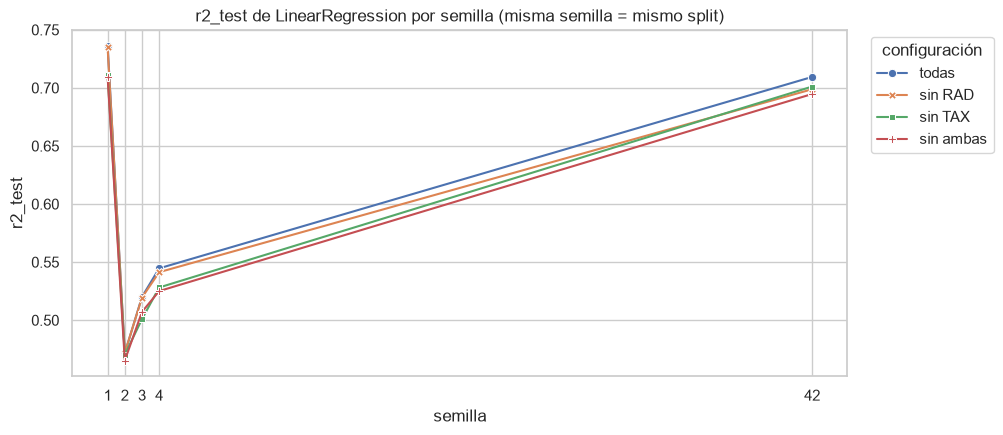

In [13]:
print('Diferencia pareada del RMSE de test contra "todas":')
display(pareado(e2, base='todas', metrica='rmse_test'))
grafico_por_semilla(e2)

**Coeficientes.** La colinealidad afecta sobre todo a la estabilidad e interpretación de los coeficientes. Se reajusta LinearRegression con cada semilla y se mira cómo varían los coeficientes (estandarizados) de TAX y RAD.

In [14]:
def coeficientes_lr(seed, excluir):
    cols_num = [c for c in COL_NUM if c not in excluir]
    X = df0[cols_num + [COL_CAT]]; Y = df0['MEDV']
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=seed, stratify=X[COL_CAT].fillna(-1))
    tr = X_train.copy(); tr[COL_CAT] = SimpleImputer(strategy='most_frequent').fit_transform(tr[[COL_CAT]]).ravel()
    rob = RobustScaler(); knn = KNNImputer(n_neighbors=5)
    tr[cols_num] = rob.inverse_transform(knn.fit_transform(rob.fit_transform(tr[cols_num])))
    for col in ['CRIM', 'DIS']:
        tr[col] = np.log1p(tr[col])
    Z = StandardScaler().fit_transform(tr)
    return pd.Series(LinearRegression().fit(Z, y_train).coef_, index=tr.columns)

filas = []
for etiqueta, excl in {'todas': (), 'sin RAD': ('RAD',), 'sin TAX': ('TAX',)}.items():
    for s in SEMILLAS:
        c = coeficientes_lr(s, excl)
        for var in ['TAX', 'RAD']:
            if var in c.index:
                filas.append({'configuracion': etiqueta, 'variable': var, 'semilla': s, 'coeficiente': c[var]})
coefs = pd.DataFrame(filas)
tabla_coefs = coefs.groupby(['configuracion', 'variable'])['coeficiente'].agg(['mean', 'std']).round(2)
tabla_coefs.to_csv('resultados/exp2_coeficientes.csv')
tabla_coefs

mean   std
configuracion variable            
sin RAD       TAX      -2.19  0.15
sin TAX       RAD      -0.73  0.14
todas         RAD       1.00  0.34
              TAX      -2.74  0.29

### 2b. La misma comparación sobre el notebook original
El notebook original (rama `aguirre`) no estratificaba el split e imputaba CHAS con CatBoost. Se repite el experimento con esa configuración para ver si la conclusión depende del resto de las decisiones.

In [15]:
BASE_ORIGINAL = dict(estratificar='none', imputar_chas='catboost' if HAY_CATBOOST else 'moda')
e2b = correr('exp2b_colinealidad_original', {'todas': dict(BASE_ORIGINAL),
                                              'sin RAD': dict(BASE_ORIGINAL, excluir=('RAD',)),
                                              'sin TAX': dict(BASE_ORIGINAL, excluir=('TAX',)),
                                              'sin ambas': dict(BASE_ORIGINAL, excluir=('RAD', 'TAX'))}, SEMILLAS)
display(resumen(e2b, 'r2_test'))
print('Diferencia pareada del R² de test contra "todas":')
pareado(e2b, base='todas', metrica='r2_test')

configuracion,todas,sin RAD,sin TAX,sin ambas
modelo,,,,
LinearRegression,0.562 ± 0.113,0.554 ± 0.114,0.554 ± 0.09,0.55 ± 0.097
Gradient Descent,0.552 ± 0.104,0.55 ± 0.095,0.547 ± 0.082,0.553 ± 0.082
Ridge,0.568 ± 0.101,0.561 ± 0.103,0.559 ± 0.084,0.555 ± 0.089
Lasso,0.555 ± 0.105,0.555 ± 0.106,0.551 ± 0.089,0.549 ± 0.094
ElasticNet,0.559 ± 0.1,0.558 ± 0.1,0.555 ± 0.082,0.553 ± 0.086


Diferencia pareada del R² de test contra "todas":


,sin RAD,sin TAX,sin ambas
LinearRegression,-0.008 ± 0.008 (peor en 5/5),-0.008 ± 0.053 (peor en 4/5),-0.013 ± 0.058 (peor en 4/5)
Gradient Descent,-0.002 ± 0.022 (peor en 3/5),-0.005 ± 0.054 (peor en 4/5),+0.000 ± 0.058 (peor en 4/5)
Ridge,-0.007 ± 0.007 (peor en 4/5),-0.009 ± 0.044 (peor en 4/5),-0.013 ± 0.048 (peor en 4/5)
Lasso,-0.000 ± 0.013 (peor en 2/5),-0.004 ± 0.049 (peor en 4/5),-0.007 ± 0.051 (peor en 4/5)
ElasticNet,-0.001 ± 0.008 (peor en 3/5),-0.004 ± 0.045 (peor en 4/5),-0.007 ± 0.045 (peor en 4/5)


## 4. Experimento 3: transformación Yeo-Johnson sobre B
**Pregunta.** B tiene una cola izquierda marcada. ¿Mejora el modelo transformarla con Yeo-Johnson (ajustado solo con train)?

In [16]:
print('Asimetría (skew) de B en el dataset:', round(df0['B'].skew(), 2))
print('Asimetría de B tras Yeo-Johnson (con todo el dataset, solo para ilustrar):',
      round(pd.Series(PowerTransformer(method='yeo-johnson', standardize=False).fit_transform(df0[['B']].dropna()).ravel()).skew(), 2))
e3 = correr('exp3_yeo_johnson', {'sin transformar': dict(), 'Yeo-Johnson en B': dict(yeo_johnson=True)}, SEMILLAS)
resumen(e3, 'r2_test')

Asimetría (skew) de B en el dataset: -2.57
Asimetría de B tras Yeo-Johnson (con todo el dataset, solo para ilustrar): -1.76


configuracion,sin transformar,Yeo-Johnson en B
modelo,,
LinearRegression,0.596 ± 0.119,0.59 ± 0.122
Gradient Descent,0.594 ± 0.115,0.59 ± 0.119
Ridge,0.597 ± 0.116,0.591 ± 0.119
Lasso,0.586 ± 0.102,0.582 ± 0.104
ElasticNet,0.587 ± 0.102,0.583 ± 0.104


,Yeo-Johnson en B
LinearRegression,-0.006 ± 0.010 (peor en 3/5)
Gradient Descent,-0.004 ± 0.011 (peor en 3/5)
Ridge,-0.006 ± 0.010 (peor en 3/5)
Lasso,-0.004 ± 0.008 (peor en 3/5)
ElasticNet,-0.004 ± 0.008 (peor en 4/5)


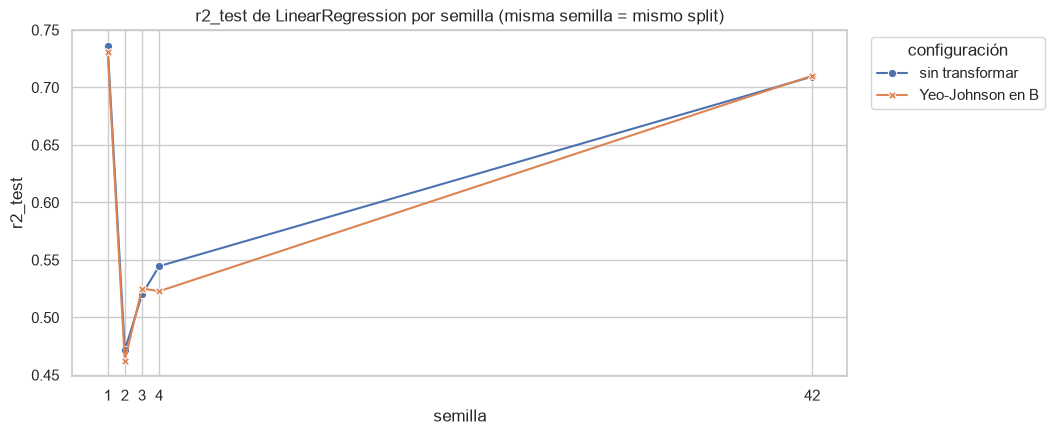

In [17]:
display(pareado(e3, base='sin transformar', metrica='r2_test'))
grafico_por_semilla(e3)

## 5. Experimento 4: cómo se eligen `lr` y `epochs` de Gradient Descent
**Pregunta.** En la versión anterior del TP, `lr` y `epochs` se elegían mirando el R² de test, lo que filtra información de test al modelo. ¿Cuánto cambia el resultado si se eligen solo con train, con un holdout o con K-Fold?

Solo cambia Gradient Descent; los demás modelos no dependen de este factor.

In [18]:
e4 = correr('exp4_seleccion_gd', {'test fijo (con fuga)': dict(metodo_gd='test_fijo'),
                                   'holdout 80/20': dict(metodo_gd='holdout'),
                                   'K-Fold (5)': dict(metodo_gd='kfold')}, SEMILLAS)
gd = e4[e4['modelo'] == 'Gradient Descent']
display(resumen(e4, 'r2_test', modelos=['Gradient Descent', 'LinearRegression']))
print('Diferencia pareada del R² de test de Gradient Descent contra "test fijo":')
display(pareado(e4, base='test fijo (con fuga)', modelos=['Gradient Descent']))
print('Hiperparámetros elegidos por semilla:')
gd.pivot(index='semilla', columns='configuracion', values='hiperparametros')

configuracion,test fijo (con fuga),holdout 80/20,K-Fold (5)
modelo,,,
Gradient Descent,0.596 ± 0.119,0.589 ± 0.112,0.594 ± 0.115
LinearRegression,0.596 ± 0.119,0.596 ± 0.119,0.596 ± 0.119


Diferencia pareada del R² de test de Gradient Descent contra "test fijo":


,K-Fold (5),holdout 80/20
Gradient Descent,-0.002 ± 0.005 (peor en 4/5),-0.008 ± 0.013 (peor en 3/5)


Hiperparámetros elegidos por semilla:


configuracion,K-Fold (5),holdout 80/20,test fijo (con fuga)
semilla,,,
1,"lr=0.01, epochs=500","lr=0.01, epochs=200","lr=0.1, epochs=200"
2,"lr=0.1, epochs=500","lr=0.1, epochs=500","lr=0.1, epochs=200"
3,"lr=0.05, epochs=200","lr=0.01, epochs=200","lr=0.1, epochs=200"
4,"lr=0.01, epochs=200","lr=0.1, epochs=500","lr=0.1, epochs=200"
42,"lr=0.01, epochs=200","lr=0.1, epochs=200","lr=0.1, epochs=200"


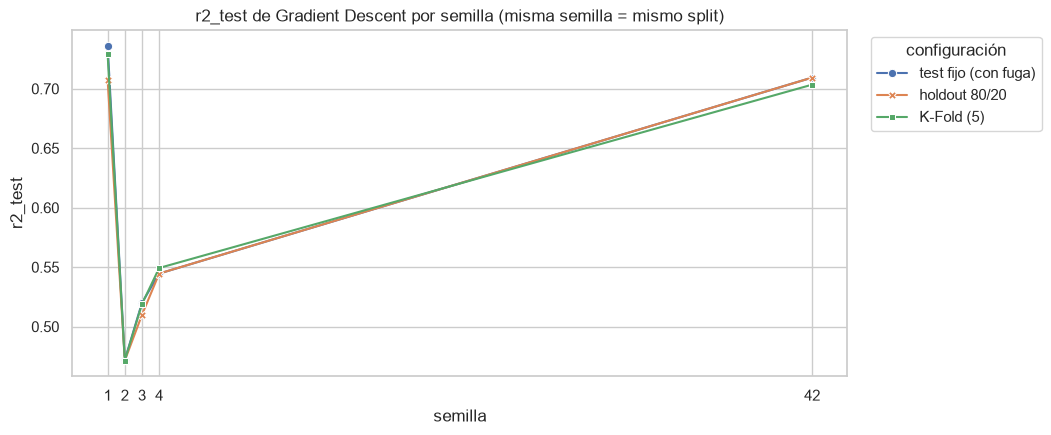

In [19]:
grafico_por_semilla(e4, modelo='Gradient Descent')

## 6. Experimento 5: grilla de `RidgeCV`
**Pregunta.** Con la grilla por defecto (0.1, 1 y 10), `RidgeCV` elige siempre el extremo superior. ¿Qué pasa con una grilla más ancha?

In [20]:
e5 = correr('exp5_grilla_ridge', {'grilla por defecto': dict(), 'grilla ancha': dict(ridge_alphas='ancha')}, SEMILLAS)
ridge = e5[e5['modelo'] == 'Ridge']
display(ridge.pivot(index='semilla', columns='configuracion', values='hiperparametros').rename_axis(columns='alpha elegido'))
display(pareado(e5, base='grilla por defecto', modelos=['Ridge']))
display(pareado(e5, base='grilla por defecto', metrica='rmse_test', modelos=['Ridge']))

alpha elegido,grilla ancha,grilla por defecto
semilla,,
1,59.6362,10.0
2,11.514,10.0
3,18.4207,10.0
4,37.2759,10.0
42,47.1487,10.0


,grilla ancha
Ridge,-0.004 ± 0.013 (peor en 3/5)


,grilla ancha
Ridge,+0.044 ± 0.112 (peor en 3/5)


## 7. Experimento 6: esquemas de estratificación
**Pregunta.** ¿Qué esquema de estratificación produce una evaluación más estable entre semillas?

Se usan 10 semillas. Los esquemas no son pareables entre sí (cambian las filas de test); lo que se compara es la **variabilidad entre semillas** de cada uno.

In [21]:
e6 = correr('exp6_esquemas_estratificacion', {'sin estratificar': dict(estratificar='none'),
                                               'por CHAS': dict(estratificar='chas'),
                                               'por MEDV (5 quintiles)': dict(estratificar='medv'),
                                               'CHAS x MEDV (3 terciles)': dict(estratificar='chas_medv')}, SEMILLAS_10)
lin = e6[e6['modelo'] == 'LinearRegression']
estab = lin.groupby('configuracion')['r2_test'].agg(media='mean', desvio='std', minimo='min', maximo='max').round(3)
estab.reindex(list(dict.fromkeys(e6['configuracion'])))

,media,desvio,minimo,maximo
configuracion,,,,
sin estratificar,0.564,0.094,0.433,0.672
por CHAS,0.600,0.088,0.471,0.736
por MEDV (5 quintiles),0.616,0.070,0.501,0.748
CHAS x MEDV (3 terciles),0.631,0.058,0.547,0.718


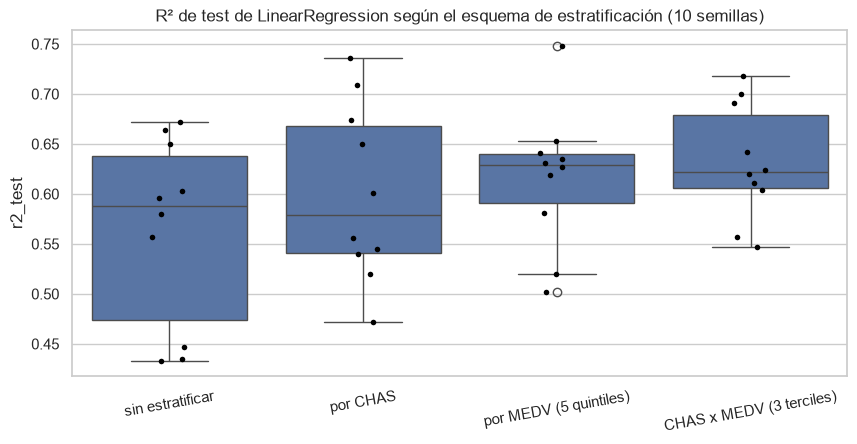

In [22]:
fig, ax = plt.subplots()
sns.boxplot(data=lin, x='configuracion', y='r2_test', ax=ax, order=list(dict.fromkeys(e6['configuracion'])))
sns.stripplot(data=lin, x='configuracion', y='r2_test', ax=ax, color='black', size=4, order=list(dict.fromkeys(e6['configuracion'])))
ax.set_title('R² de test de LinearRegression según el esquema de estratificación (10 semillas)'); ax.set_xlabel('')
plt.xticks(rotation=10); plt.show()

In [23]:
# Lo mismo para los modelos regularizados
resumen(e6, 'r2_test', modelos=['LinearRegression', 'Ridge', 'Lasso', 'ElasticNet'])

configuracion,sin estratificar,por CHAS,por MEDV (5 quintiles),CHAS x MEDV (3 terciles)
modelo,,,,
LinearRegression,0.564 ± 0.094,0.6 ± 0.088,0.616 ± 0.07,0.631 ± 0.058
Ridge,0.569 ± 0.085,0.602 ± 0.086,0.617 ± 0.067,0.63 ± 0.056
Lasso,0.564 ± 0.086,0.594 ± 0.077,0.612 ± 0.063,0.623 ± 0.063
ElasticNet,0.566 ± 0.082,0.596 ± 0.077,0.608 ± 0.06,0.622 ± 0.055


## 8. Resumen de las diferencias pareadas
Diferencia de R² de test de LinearRegression respecto de la configuración base de cada experimento (media ± desvío entre semillas). Las cifras se calculan a partir de las tablas anteriores.

In [24]:
resumen_final = []
for nombre, df, base in [('2. Colinealidad', e2, 'todas'), ('3. Yeo-Johnson en B', e3, 'sin transformar'),
                         ('5. Grilla de Ridge (Ridge)', e5, 'grilla por defecto')]:
    modelo = 'Ridge' if 'Ridge' in nombre else 'LinearRegression'
    tabla = pareado(df, base=base, modelos=[modelo])
    for conf, valor in tabla.loc[modelo].items():
        resumen_final.append({'experimento': nombre, 'configuración': conf, 'Δ R² de test vs base': valor})
pd.DataFrame(resumen_final)

,experimento,configuración,Δ R² de test vs base
0,2. Colinealidad,sin RAD,-0.003 ± 0.004 (peor en 4/5)
1,2. Colinealidad,sin TAX,-0.014 ± 0.010 (peor en 5/5)
2,2. Colinealidad,sin ambas,-0.016 ± 0.008 (peor en 5/5)
3,3. Yeo-Johnson en B,Yeo-Johnson en B,-0.006 ± 0.010 (peor en 3/5)
4,5. Grilla de Ridge (Ridge),grilla ancha,-0.004 ± 0.013 (peor en 3/5)


## Cómo leer los resultados
- Una diferencia pareada cuya media es pequeña comparada con su desvío, y que cambia de signo entre semillas, no es evidencia de que la configuración mejore o empeore el modelo.
- Una diferencia con el mismo signo en todas las semillas y desvío chico es un efecto consistente, aunque su magnitud puede ser muy pequeña.
- Con 5 semillas (10 en el experimento 6) los estadísticos son orientativos, no una prueba.
- Las conclusiones y las decisiones tomadas a partir de estos resultados están en [`../EXPERIMENTOS.md`](../EXPERIMENTOS.md).